# Figure: Promoter / feature embedding clustering of Shorkie LM representations

This figure visualizes the Shorkie language-model (LM) sequence embeddings of genomic features (genes, intergenic regions, promoters, tRNAs, transposable elements) projected to 2-D and colored by annotation class. Sequence windows are embedded by the pretrained fungal masked-DNA LM, the per-window embeddings are reduced with a 2-D manifold projection, and each point is colored by its genome-feature / gene-biotype label so that biologically distinct element types separate into clusters.

**Reproduces:** the promoter/feature embedding scatter (LM-embedding clustering panel).

**Upstream:** `scripts/04_analysis/shorkie_lm/umap_cluster_promoter/1_predict_seqs_LM.py` runs the trained LM (`models.shorkie_lm`) over each chromosome and writes `embeddings_chr*.h5` (datasets `embeddings_<layer>` plus a `metadata` table) under `results.umap`. This notebook consumes those `.h5` files; it does **not** re-run the LM.

**Requires:** the `yeast_ml` conda env with this repo installed (`pip install -e .`); no GPU (loads precomputed embeddings, runs CPU t-SNE). To produce the input artifact you must first run the upstream stage on a GPU.

**Source script:** ported from `scripts/04_analysis/shorkie_lm/umap_cluster_promoter/2_viz_clusters_LM.py` (the feature-colored embedding scatter; `3_viz_clusters_LM_clustering.py` adds the K-Means variant). Note: the source uses scikit-learn `TSNE` for the 2-D projection (the panel is labeled a UMAP-style embedding map); this notebook keeps the original t-SNE to reproduce the published layout faithfully.

In [1]:
import glob
import os
import warnings

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pyranges as pr

from shorkie import config

In [2]:
# Resolve paths from config (no hardcoded absolute paths).
# results.umap holds the upstream LM embedding artifacts (embeddings_chr*.h5).
umap_dir = config.path("results.umap")
embedding_pattern = str(umap_dir / "embeddings_LM_sequence" / "embeddings_chr*.h5")
gtf_file = str(config.path("genome.gtf"))

print("Embedding glob :", embedding_pattern)
print("GTF file       :", gtf_file)

Embedding glob : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/UMAP_cluster_promoter/embeddings_LM_sequence/embeddings_chr*.h5
GTF file       : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/data/yeast/ensembl_fungi_59/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI/data_r64_gtf/gtf/GCA_000146045_2.59.gtf


In [3]:
# Load every per-chromosome HDF5: stack embeddings by dataset name and concatenate metadata.
files = sorted(glob.glob(embedding_pattern))
assert files, f"No embedding files found at {embedding_pattern}. Run the upstream stage 1_predict_seqs_LM.py first."
print(f"Found {len(files)} embedding files:")
for f in files:
    print("  ", os.path.basename(f))

embeddings_data = {}
meta_list = []
for f in files:
    with h5py.File(f, "r") as h5f:
        if "metadata" in h5f:
            meta_list.append(np.array(h5f["metadata"]))
        else:
            warnings.warn(f"'metadata' not found in {f}.")
        for ds in h5f.keys():
            if ds.startswith("embeddings_"):
                embeddings_data.setdefault(ds, []).append(np.array(h5f[ds]))

print("Embedding datasets:", list(embeddings_data.keys()))

Found 16 embedding files:
   embeddings_chrI.h5
   embeddings_chrII.h5
   embeddings_chrIII.h5
   embeddings_chrIV.h5
   embeddings_chrIX.h5
   embeddings_chrV.h5
   embeddings_chrVI.h5
   embeddings_chrVII.h5
   embeddings_chrVIII.h5
   embeddings_chrX.h5
   embeddings_chrXI.h5
   embeddings_chrXII.h5
   embeddings_chrXIII.h5
   embeddings_chrXIV.h5
   embeddings_chrXV.h5
   embeddings_chrXVI.h5


Embedding datasets: ['embeddings_dense', 'embeddings_dense_1', 'embeddings_dense_14', 'embeddings_dense_15', 'embeddings_dense_16', 'embeddings_dense_28', 'embeddings_dense_29', 'embeddings_max_pooling1d_6', 'embeddings_multihead_attention', 'embeddings_multihead_attention_7']


In [4]:
# Build the combined metadata table: chrom/start/end/strand/feature/gene_id.
meta_arr = np.concatenate(meta_list, axis=0)
meta_str = np.char.decode(meta_arr.astype(np.bytes_), "utf-8")
meta_df = pd.DataFrame(meta_str, columns=["chrom", "start", "end", "strand", "feature", "gene_id"])
meta_df[["start", "end"]] = meta_df[["start", "end"]].apply(pd.to_numeric, errors="coerce")
meta_df = meta_df.reset_index(drop=True)
meta_df["original_feature"] = meta_df["feature"]
print("Metadata rows:", len(meta_df))
meta_df.head()

Metadata rows: 16518


,chrom,start,end,strand,feature,gene_id,original_feature
0,chrI,36008,36508,+,promoter,YAL059W,promoter
1,chrI,124295,124306,nan,intergenic,intergenic,intergenic
2,chrI,51707,51854,nan,intergenic,intergenic,intergenic
3,chrI,220197,220497,+,gene,YAR064W,gene
4,chrI,79488,79842,-,gene,YAL034C-B,gene


In [5]:
# Refine generic 'gene' rows with the gene_biotype from the GTF (e.g. protein_coding, tRNA, ...).
gtf_df = pr.read_gtf(gtf_file).as_df()
if "gene_biotype" in gtf_df.columns:
    gene_info = gtf_df[["gene_id", "gene_biotype"]].drop_duplicates()
    meta_df = meta_df.merge(gene_info, on="gene_id", how="left")
    is_gene = (meta_df["feature"] == "gene") & meta_df["gene_biotype"].notna()
    meta_df.loc[is_gene, "feature"] = meta_df.loc[is_gene, "gene_biotype"]
else:
    warnings.warn("No 'gene_biotype' column in GTF; keeping raw feature labels.")

print("Feature labels:", sorted(meta_df["feature"].unique()))

Feature labels: ['intergenic', 'ncRNA', 'promoter', 'protein_coding', 'pseudogene', 'rRNA', 'snRNA', 'snoRNA', 'tRNA', 'transposable_element']


In [6]:
# Select the feature groups shown in the figure and drop noisy minor classes (matches 2_viz_clusters_LM.sh).
include_groups = ["gene", "intergenic", "promoter", "tRNA", "transposable_element"]
exclude_groups = ["snoRNA", "ncRNA", "pseudogene", "snRNA", "rRNA"]

mask = meta_df["original_feature"].isin(include_groups)
mask &= ~meta_df["feature"].isin(exclude_groups)
meta_df_filt = meta_df.loc[mask].copy()

# Map raw labels to human-readable names for the legend.
nice = {
    "protein_coding": "Protein-coding gene",
    "intergenic": "Intergenic region",
    "tRNA": "tRNA",
    "transposable_element": "Transposable element",
    "promoter": "Promoter",
}
meta_df_filt["feature"] = meta_df_filt["feature"].map(lambda x: nice.get(x, x))
print(f"After filtering: {len(meta_df_filt)} rows; features = {sorted(meta_df_filt['feature'].unique())}")

After filtering: 16384 rows; features = ['Intergenic region', 'Promoter', 'Protein-coding gene', 'Transposable element', 'tRNA']


In [7]:
# Pick one embedding dataset, project to 2-D with t-SNE (random_state=42, matching the source).
ds_name = next(iter(embeddings_data))
all_emb = np.concatenate(embeddings_data[ds_name], axis=0)
assert all_emb.shape[0] == len(meta_df), f"Row mismatch for {ds_name}: {all_emb.shape[0]} vs {len(meta_df)}"
emb = all_emb[mask.values]
print(f"Projecting {ds_name} embeddings of shape {emb.shape} with t-SNE...")

tsne = TSNE(n_components=2, random_state=42, verbose=1)
proj = tsne.fit_transform(emb)

Projecting embeddings_dense embeddings of shape (16384, 768) with t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 16384 samples in 0.008s...


[t-SNE] Computed neighbors for 16384 samples in 4.042s...


[t-SNE] Computed conditional probabilities for sample 1000 / 16384
[t-SNE] Computed conditional probabilities for sample 2000 / 16384
[t-SNE] Computed conditional probabilities for sample 3000 / 16384
[t-SNE] Computed conditional probabilities for sample 4000 / 16384
[t-SNE] Computed conditional probabilities for sample 5000 / 16384
[t-SNE] Computed conditional probabilities for sample 6000 / 16384
[t-SNE] Computed conditional probabilities for sample 7000 / 16384
[t-SNE] Computed conditional probabilities for sample 8000 / 16384
[t-SNE] Computed conditional probabilities for sample 9000 / 16384
[t-SNE] Computed conditional probabilities for sample 10000 / 16384


[t-SNE] Computed conditional probabilities for sample 11000 / 16384
[t-SNE] Computed conditional probabilities for sample 12000 / 16384
[t-SNE] Computed conditional probabilities for sample 13000 / 16384
[t-SNE] Computed conditional probabilities for sample 14000 / 16384
[t-SNE] Computed conditional probabilities for sample 15000 / 16384
[t-SNE] Computed conditional probabilities for sample 16000 / 16384
[t-SNE] Computed conditional probabilities for sample 16384 / 16384
[t-SNE] Mean sigma: 0.191216


[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.853981


[t-SNE] KL divergence after 1000 iterations: 2.255708


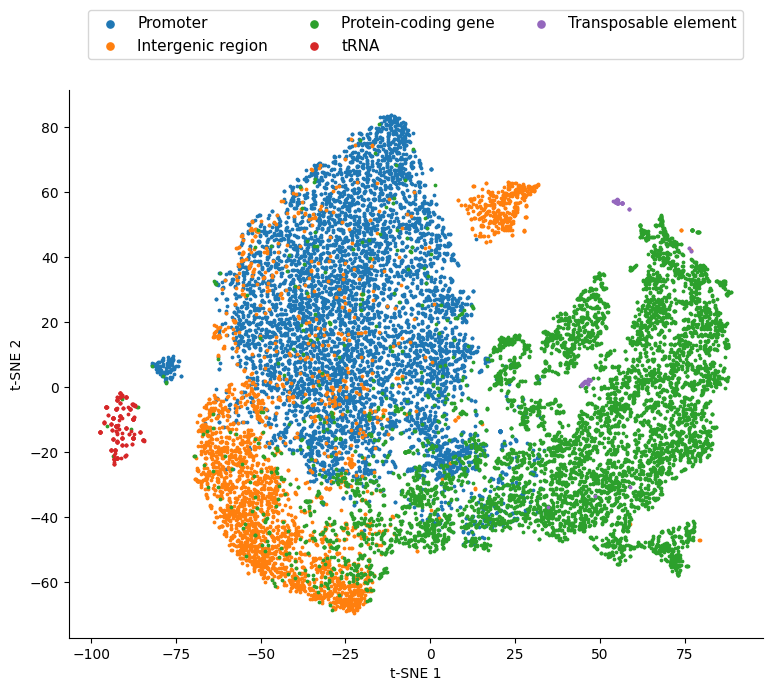

In [8]:
# Scatter the 2-D embedding, one color per feature class (fixed 5-color palette, as in the source).
palette = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
feats = meta_df_filt["feature"].unique()
color_map = {f: palette[i % len(palette)] for i, f in enumerate(feats)}

fig, ax = plt.subplots(figsize=(8, 7))
for f in feats:
    idx = (meta_df_filt["feature"] == f).values
    ax.scatter(proj[idx, 0], proj[idx, 1], s=3, alpha=1.0, label=f, color=color_map[f])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(bbox_to_anchor=(0.5, 1.16), loc="upper center", ncol=3, fontsize=11, markerscale=3)
fig.tight_layout()
plt.show()